# Final Report - AdaBoost

### Step 1: 載入資料與預處理
載入資料並進行訓練/測試集切分。**注意：本次實驗不使用 SMOTE。**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

# ── 1. 載入資料，排除序號欄 ────────────────────────────────
df = pd.read_csv('processed_data.csv')
df = df.drop(columns=['序號'])

# ── 2. 特徵與目標變數 ──────────────────────────────────────
X = df.drop(columns=['Y_事故嚴重度']).fillna(0)
y = df['Y_事故嚴重度']

features = X.columns.tolist()
print(f"特徵數量：{len(features)}")

# ── 3. 切分訓練集 / 測試集 ────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"訓練集：{len(X_train)} 筆，測試集：{len(X_test)} 筆")
print(f"\n訓練集 Y 分布：\n{y_train.value_counts()}")
print(f"\n測試集 Y 分布：")
print(y_test.value_counts())
print(f"\n訓練集：{len(X_train)} 筆，測試集：{len(X_test)} 筆")

# Mac 內建的支援中文的字體
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] 
# 或者是 plt.rcParams['font.sans-serif'] = ['PingFang TC']

# 解決負號 ('-') 顯示為方塊的問題
plt.rcParams['axes.unicode_minus'] = False

# Windows 使用微軟正黑體 (Mac 若需使用請改為 'Arial Unicode MS' 或 'PingFang TC')
# plt.rcParams['font.family'] = 'Microsoft JhengHei'
# plt.rcParams['axes.unicode_minus'] = False

: 

### Step 2: Modeling (建立模型與交叉驗證)
由於沒有使用 SMOTE，我們必須利用 AdaBoost 的 `class_weight='balanced'` 參數來處理資料不平衡。
`class_weight='balanced'` 的建議設定值為：**負樣本數 / 正樣本數**。

In [31]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ── 1. 定義初步 AdaBoost 模型 ─────────────────────────────
# 使用帶有 class_weight='balanced' 的 DecisionTree 來處理不平衡
base_estimator = DecisionTreeClassifier(max_depth=1,class_weight='balanced', random_state=42)
ada_model = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# ── 2. 10-fold 交叉驗證 ────────────────────────────────────
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_recall = cross_val_score(
    ada_model, X_train, y_train, 
    cv=cv, scoring='recall', n_jobs=-1
)

cv_f1 = cross_val_score(
    ada_model, X_train, y_train,
    cv=cv, scoring='f1', n_jobs=-1
)

print("\n【預設參數】10-fold 交叉驗證結果：")
print(f"  Recall : {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
print(f"  F1     : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

# ── 3. 訓練模型 ─────────────────────────────────────────
ada_model.fit(X_train, y_train)
print("\n初步 AdaBoost 模型訓練完成！")


【預設參數】10-fold 交叉驗證結果：
  Recall : 0.2614 ± 0.0160
  F1     : 0.3716 ± 0.0189

初步 AdaBoost 模型訓練完成！


### Step 3: Hyperparameter Tuning (超參數調優)
使用 GridSearchCV 尋找最佳的 `n_estimators`、`max_depth` 與 `learning_rate`。
確保在參數網格中包含我們計算出的 `class_weight='balanced'`。

In [32]:
from sklearn.model_selection import GridSearchCV

# ── 1. 定義 AdaBoost 參數網格 ──────────────────────────────
param_grid_ada = {
    'n_estimators': [50, 100, 200, 300], 
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.5],
    'estimator__max_depth': [3,5,7]
}

# ── 2. Grid Search (10 折交叉驗證) ─────────────────────────
grid_search_ada = GridSearchCV(
    AdaBoostClassifier(estimator=base_estimator, random_state=42),
    param_grid_ada,
    cv=10,              # 使用 10-fold CV
    scoring='f1',   # 以 Recall 作為主要優化目標
    n_jobs=-1,
    verbose=1           # 執行時會顯示進度資訊
)

grid_search_ada.fit(X_train, y_train)

# ── 3. 整理與輸出結果 ─────────────────────────────────────
results_ada = pd.DataFrame(grid_search_ada.cv_results_)

summary_ada = results_ada[[
    'param_n_estimators', 'param_learning_rate','param_estimator__max_depth',
    'mean_test_score', 'std_test_score', 'rank_test_score'
]]
summary_ada = summary_ada.rename(columns={
    'mean_test_score': 'Recall（平均）',
    'std_test_score': 'Recall（標準差）',
    'rank_test_score': '排名'
}).sort_values('排名')

print("\n超參數調優結果摘要 (前 5 名)：")
display(summary_ada.head(5))

print(f"\n最佳參數：{grid_search_ada.best_params_}")
print(f"最佳 Recall（10-CV）：{grid_search_ada.best_score_:.4f}")

# ── 4. 取得最佳模型 ───────────────────────────────────────
best_ada = grid_search_ada.best_estimator_
print("\n最佳 AdaBoost 模型準備完畢！")

Fitting 10 folds for each of 60 candidates, totalling 600 fits

超參數調優結果摘要 (前 5 名)：


,param_n_estimators,param_learning_rate,param_estimator__max_depth,Recall（平均）,Recall（標準差）,排名
18,200,0.5,3,0.618445,0.025185,1
17,100,0.5,3,0.618445,0.025185,1
16,50,0.5,3,0.618445,0.025185,1
19,300,0.5,3,0.618445,0.025185,1
59,300,0.5,7,0.602987,0.019187,5



最佳參數：{'estimator__max_depth': 3, 'learning_rate': 0.5, 'n_estimators': 50}
最佳 Recall（10-CV）：0.6184

最佳 AdaBoost 模型準備完畢！


### Step 4: Evaluation (模型評估)
在測試集上進行預測，並計算各項評估指標、分類報告以及繪製混淆矩陣。

指標                AdaBoost 最佳模型
Accuracy                 0.5750
Precision                0.6050
Recall                   0.6943
F1-score                 0.6466
ROC-AUC                  0.5703
PR-AUC                   0.6027

Classification Report:
              precision    recall  f1-score   support

     非致命 (0)       0.52      0.42      0.47      1687
      致命 (1)       0.60      0.69      0.65      2146

    accuracy                           0.58      3833
   macro avg       0.56      0.56      0.56      3833
weighted avg       0.57      0.58      0.57      3833



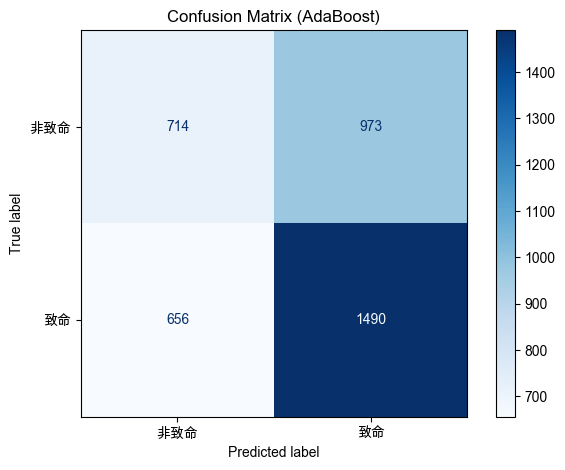

In [34]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# ── 1. 在測試集上進行預測 ─────────────────────────────────
y_pred_ada = best_ada.predict(X_test)
y_prob_ada = best_ada.predict_proba(X_test)[:, 1]

# ── 2. 指標輸出 ──────────────────────────────────────────
print("=" * 45)
print(f"{'指標':<15} {'AdaBoost 最佳模型':>15}")
print("=" * 45)
print(f"{'Accuracy':<15} {accuracy_score(y_test, y_pred_ada):>15.4f}")
print(f"{'Precision':<15} {precision_score(y_test, y_pred_ada):>15.4f}")
print(f"{'Recall':<15} {recall_score(y_test, y_pred_ada):>15.4f}")
print(f"{'F1-score':<15} {f1_score(y_test, y_pred_ada):>15.4f}")
print(f"{'ROC-AUC':<15} {roc_auc_score(y_test, y_prob_ada):>15.4f}")
print(f"{'PR-AUC':<15} {average_precision_score(y_test, y_prob_ada):>15.4f}")
print("=" * 45)

# ── 3. 分類報告 ──────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ada, target_names=['非致命 (0)', '致命 (1)']))

# ── 4. 混淆矩陣 (Confusion Matrix) ────────────────────────
cm_ada = confusion_matrix(y_test, y_pred_ada)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ada, display_labels=['非致命', '致命'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (AdaBoost)')
plt.tight_layout()
plt.show()

### Step 5: Interpretation (模型解釋 - SHAP)
利用 SHAP (SHapley Additive exPlanations) 來拆解 AdaBoost 模型，觀察特徵的全局重要性與單一案例的判斷邏輯。

PermutationExplainer explainer: 3834it [03:26, 17.72it/s]                          


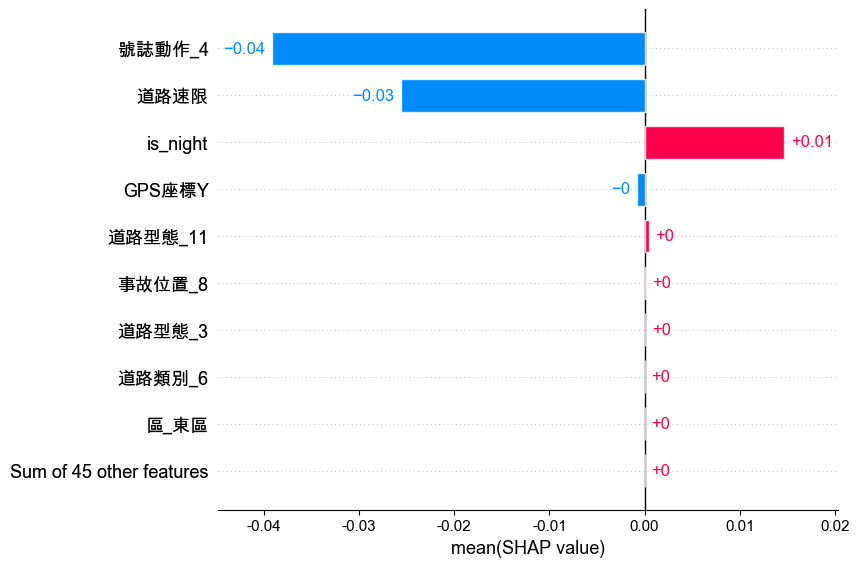

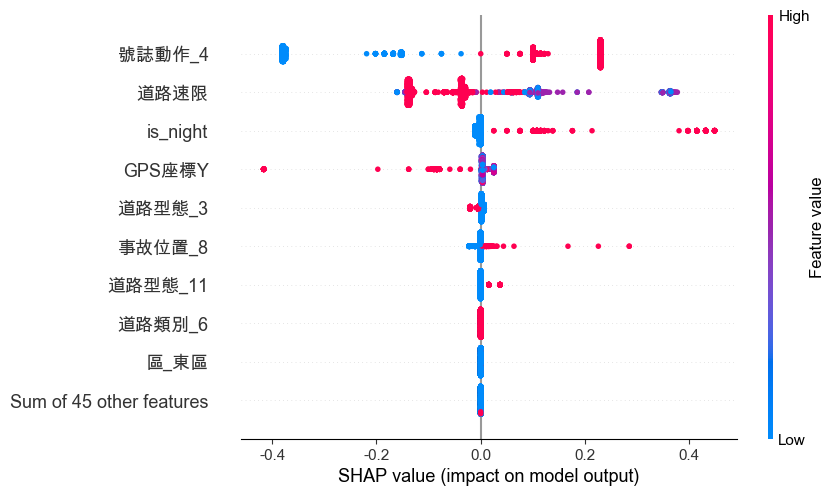

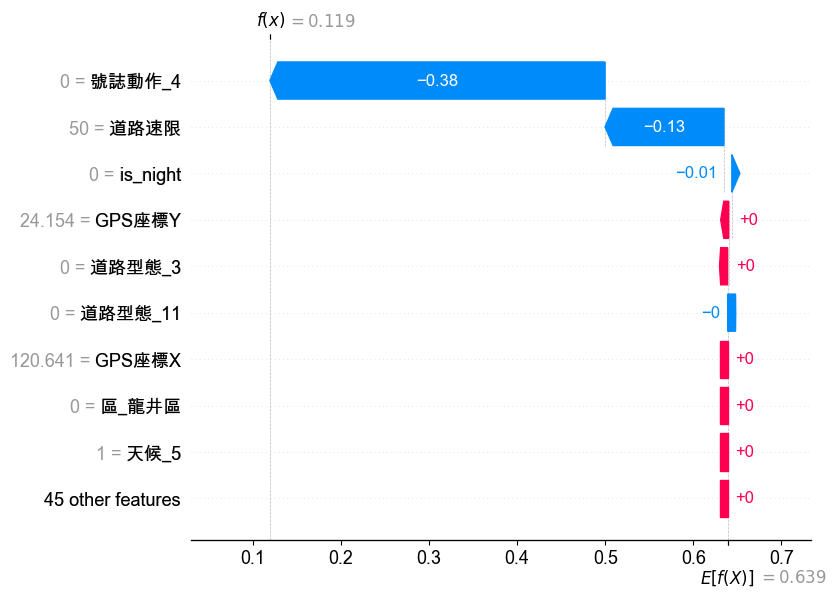

In [35]:
import shap
import numpy as np

# ── 1. 建立 SHAP PermutationExplainer ────────────────────
explainer_ada = shap.PermutationExplainer(
    best_ada.predict_proba,
    X_train.iloc[:200]          # 背景資料
)

# 計算 SHAP 值（回傳 Explanation 物件，shape: [樣本, 特徵, 類別]）
shap_values_ada = explainer_ada(X_test)

# ── 2. Summary Bar Plot：全局特徵重要性 ──────────────────
shap.plots.bar(
    shap_values_ada[:, :, 1].mean(0),   # 正類（致命）的平均絕對 SHAP 值
    show=True
)

# ── 3. Beeswarm Plot：特徵影響方向 ───────────────────────
shap.plots.beeswarm(
    shap_values_ada[:, :, 1],           # 正類（致命）
    show=True
)

# ── 4. Waterfall Plot：單一致命案例解析 ──────────────────
# 找出測試集中第一筆實際為「致命」(1) 的資料索引
fatal_idx = np.where(y_test.values == 1)[0][0]

shap.plots.waterfall(
    shap_values_ada[fatal_idx, :, 1]    # 正類（致命）
)

In [36]:
import numpy as np
import pandas as pd

# 1. 取得新進資料預測為「嚴重事故 (1)」的機率
# 假設 best_ada 是您訓練好的模型，X_new 是即時的交通事故特徵
y_prob = best_ada.predict_proba(X_test)[:, 1]

# 2. 設定您的閾值 (Thresholds)
high_thresh = 0.7
med_thresh = 0.3

# 3. 定義邏輯條件與對應的策略
conditions = [
    (y_prob >= high_thresh),
    (y_prob >= med_thresh) & (y_prob < high_thresh),
    (y_prob < med_thresh)
]

risk_tiers = ['高風險', '中風險', '低風險']
actions = ['優先派遣警力或加強巡邏', '定期巡查', '維持現狀']

# 4. 產出決策報表
df_decisions = pd.DataFrame({'嚴重事故預測機率': y_prob})

# 加上 default='未知' 或其他字串，讓 NumPy 知道遇到例外時該填什麼字串
df_decisions['風險等級'] = np.select(conditions, risk_tiers, default='未知')
df_decisions['決策策略'] = np.select(conditions, actions, default='無動作')

# 檢視高風險且需要立即派警力的清單，並依機率高低排序
df_dispatch = df_decisions[df_decisions['風險等級'] == '高風險'].sort_values(by='嚴重事故預測機率', ascending=False)
display(df_dispatch.head(100))

,嚴重事故預測機率,風險等級,決策策略
1112,0.880797,高風險,優先派遣警力或加強巡邏
891,0.880797,高風險,優先派遣警力或加強巡邏
1762,0.880797,高風險,優先派遣警力或加強巡邏
3174,0.880797,高風險,優先派遣警力或加強巡邏
2585,0.880797,高風險,優先派遣警力或加強巡邏
...,...,...,...
3108,0.880797,高風險,優先派遣警力或加強巡邏
3107,0.880797,高風險,優先派遣警力或加強巡邏
2613,0.880797,高風險,優先派遣警力或加強巡邏
839,0.880797,高風險,優先派遣警力或加強巡邏


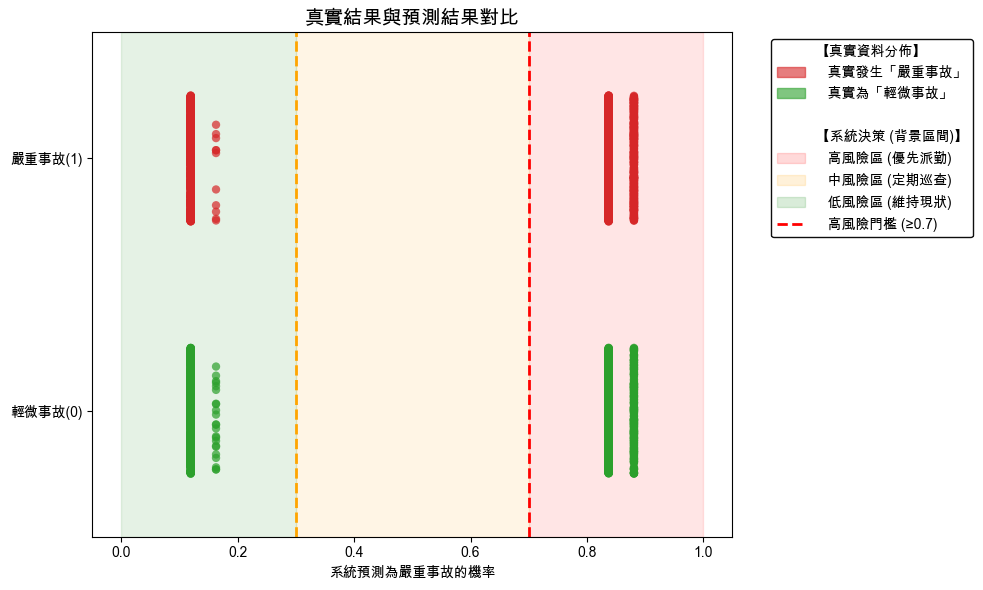

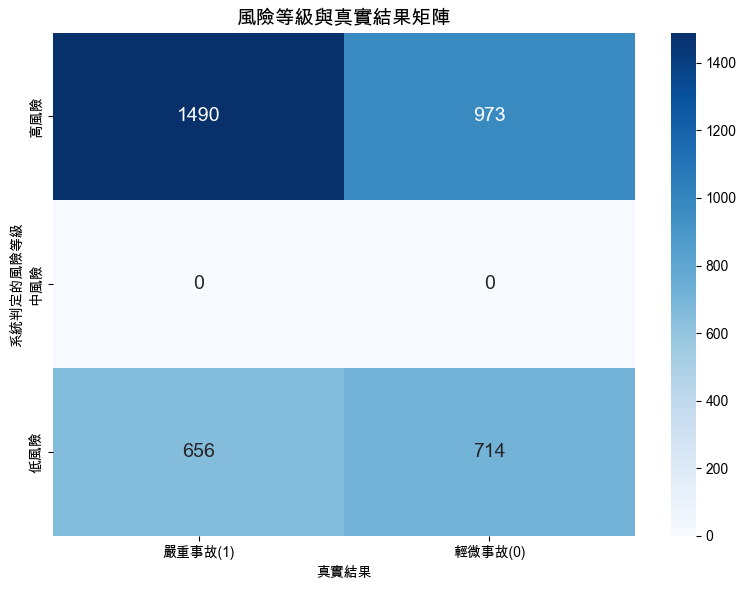


【案件決策與真實情況比對表 (依高風險排序)】


,嚴重事故預測機率,風險等級,決策策略,真實結果標籤
13046,0.119203,低風險,維持現狀,輕微事故(0)
14617,0.119203,低風險,維持現狀,輕微事故(0)
9313,0.119203,低風險,維持現狀,嚴重事故(1)
10991,0.119203,低風險,維持現狀,輕微事故(0)
7062,0.119203,低風險,維持現狀,輕微事故(0)
10878,0.119203,低風險,維持現狀,輕微事故(0)
16918,0.119203,低風險,維持現狀,輕微事故(0)
8117,0.119203,低風險,維持現狀,輕微事故(0)
18212,0.119203,低風險,維持現狀,輕微事故(0)
6965,0.119203,低風險,維持現狀,嚴重事故(1)


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from IPython.display import display

# 設定支援中文的字體 (依您的作業系統調整，Windows通常用 'Microsoft JhengHei')
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 1. 取得預測機率
y_prob = best_ada.predict_proba(X_test)[:, 1]

# 2. 產出決策報表：新增「真實結果」欄位
df_decisions = pd.DataFrame({
    '嚴重事故預測機率': y_prob,
    '真實結果': y_test.values  # 放入真實的 0 或 1
}, index=y_test.index) # 保留原本測試集的 index 方便後續查閱異常案件

# 3. 設定閾值與決策邏輯
high_thresh = 0.7
med_thresh = 0.3

conditions = [
    (df_decisions['嚴重事故預測機率'] >= high_thresh),
    (df_decisions['嚴重事故預測機率'] >= med_thresh) & (df_decisions['嚴重事故預測機率'] < high_thresh),
    (df_decisions['嚴重事故預測機率'] < med_thresh)
]
risk_tiers = ['高風險', '中風險', '低風險']
actions = ['優先派遣警力', '定期巡查', '維持現狀']

df_decisions['風險等級'] = np.select(conditions, risk_tiers, default='未知')
df_decisions['決策策略'] = np.select(conditions, actions, default='無動作')
df_decisions['真實結果標籤'] = df_decisions['真實結果'].map({1: '嚴重事故(1)', 0: '輕微事故(0)'})


# ================= 視覺化圖表繪製 (圖表一) =================
# 建立第一張圖：獨立的機率分佈散點圖
plt.figure(figsize=(10, 6))

sns.stripplot(data=df_decisions, x='嚴重事故預測機率', y='真實結果標籤', 
              hue='真實結果標籤', 
              palette={'嚴重事故(1)': '#d62728', '輕微事故(0)': '#2ca02c'}, 
              order=['嚴重事故(1)', '輕微事故(0)'], 
              jitter=0.25, alpha=0.7, size=6, legend=False)

# 畫上決策門檻虛線
plt.axvline(high_thresh, color='red', linestyle='--', linewidth=2)
plt.axvline(med_thresh, color='orange', linestyle='--', linewidth=2)

# 填滿背景風險區塊顏色 (視覺化紅黃綠區)
plt.axvspan(high_thresh, 1.0, color='red', alpha=0.1)       
plt.axvspan(med_thresh, high_thresh, color='orange', alpha=0.1) 
plt.axvspan(0.0, med_thresh, color='green', alpha=0.1)      

# 建立階層式的完美圖例說明
legend_elements = [
    mlines.Line2D([], [], color='none', label='【真實資料分佈】'),
    mpatches.Patch(color='#d62728', alpha=0.6, label='   真實發生「嚴重事故」'),
    mpatches.Patch(color='#2ca02c', alpha=0.6, label='   真實為「輕微事故」'),
    mlines.Line2D([], [], color='none', label=' '),
    mlines.Line2D([], [], color='none', label='【系統決策 (背景區間)】'),
    mpatches.Patch(color='red', alpha=0.15, label='   高風險區 (優先派勤)'),
    mpatches.Patch(color='orange', alpha=0.15, label='   中風險區 (定期巡查)'),
    mpatches.Patch(color='green', alpha=0.15, label='   低風險區 (維持現狀)'),
    mlines.Line2D([], [], color='red', linestyle='--', linewidth=2, label=f'   高風險門檻 (≥{high_thresh})'),
]

# 將圖例放置於圖表「外側」右上方 (bbox_to_anchor 控制位置)
plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', 
           fontsize=10, title='', title_fontsize=12, framealpha=0.95, edgecolor='black', labelspacing=0.5)

plt.title('真實結果與預測結果對比', fontsize=14, fontweight='bold')
plt.xlabel('系統預測為嚴重事故的機率')
plt.ylabel('') 
plt.tight_layout()
plt.show()


# ================= 視覺化圖表繪製 (圖表二) =================
# 建立第二張圖：獨立的熱力圖
plt.figure(figsize=(8, 6))

crosstab = pd.crosstab(df_decisions['風險等級'], df_decisions['真實結果標籤'])
# 加入 fill_value=0，避免無資料時產生 NaN 導致型態變成 float
crosstab = crosstab.reindex(['高風險', '中風險', '低風險'], fill_value=0) 

sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 14})
plt.title('風險等級與真實結果矩陣', fontsize=14, fontweight='bold')
plt.xlabel('真實結果')
plt.ylabel('系統判定的風險等級')

plt.tight_layout()
plt.show()


# ================= 預測結果與真實情況明細表 =================
print("\n【案件決策與真實情況比對表 (依高風險排序)】")
# 整理欲輸出的欄位
df_summary = df_decisions[['嚴重事故預測機率', '風險等級', '決策策略', '真實結果標籤']].copy()
# 依照危險程度由高至低排序
df_summary = df_summary.sort_values(by='嚴重事故預測機率', ascending=False)

# 顯示前 15 筆
display(df_summary.tail(15))

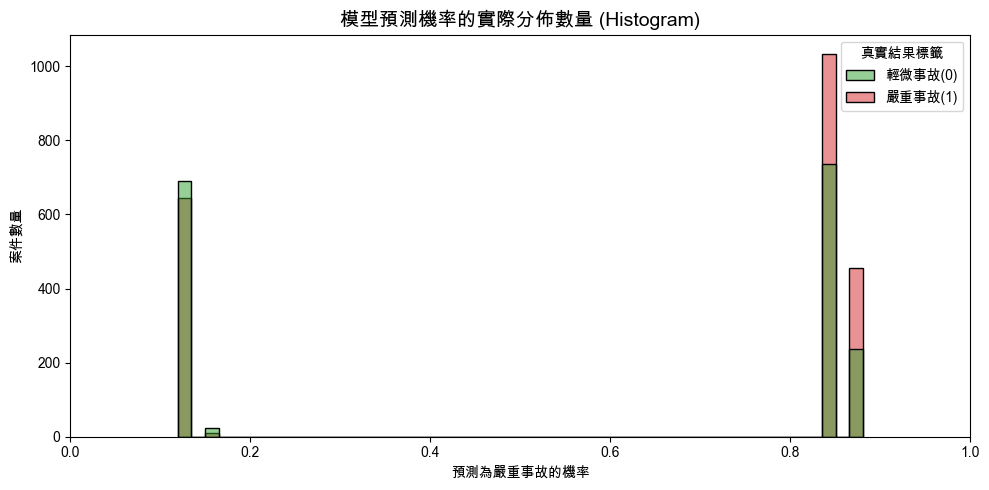

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
# 畫出 0 到 1 之間的機率分佈，切成 50 個區塊 (bins)
sns.histplot(data=df_decisions, x='嚴重事故預測機率', hue='真實結果標籤', 
             bins=50, kde=False, palette={'嚴重事故(1)': '#d62728', '輕微事故(0)': '#2ca02c'})

plt.title('模型預測機率的實際分佈數量 (Histogram)', fontsize=14)
plt.xlabel('預測為嚴重事故的機率')
plt.ylabel('案件數量')
plt.xlim(0, 1) # 強制 X 軸顯示 0 到 1
plt.tight_layout()
plt.show()

In [39]:
# ================= 查詢指定機率範圍內的案件 =================

# 1. 設定您想查詢的機率範圍 (例如：0.3 到 0.5 之間)
lower_bound = 0.3
upper_bound = 0.5

# 2. 建立篩選條件 (Mask)
mask = (df_decisions['嚴重事故預測機率'] >= lower_bound) & (df_decisions['嚴重事故預測機率'] < upper_bound)

# 3. 取出符合條件的資料子集
df_in_range = df_decisions[mask]

# 4. 計算數量與比例
count_in_range = len(df_in_range)
total_count = len(df_decisions)
proportion = count_in_range / total_count

print(f"📊 【查詢結果】")
print(f"預測機率落在 {lower_bound} ~ {upper_bound} 之間的案件共有：{count_in_range} 筆")
print(f"佔整體測試集 ({total_count} 筆) 的比例：{proportion:.2%}\n")

# 5. 進一步分析：這些落在該區間的案件，真實結果到底是什麼？
if count_in_range > 0:
    print("這些案件的真實結果分佈：")
    display(df_in_range['真實結果標籤'].value_counts().to_frame(name='案件數量'))
else:
    print("該機率範圍內沒有任何案件。")

📊 【查詢結果】
預測機率落在 0.3 ~ 0.5 之間的案件共有：0 筆
佔整體測試集 (3833 筆) 的比例：0.00%

該機率範圍內沒有任何案件。
